# SimpleCNN：本机 checkpoint 样本检查

本笔记本在 `linetracker-py311` 环境中加载 NPU 集群训练得到的 checkpoint，直接对本机合成数据的单个 20 帧时间窗做推理与可视化。

- 使用全部 34 个标准距离块做一次候选线推理；
- 显示按预测 $q$ 排序的候选表、目标附近时距图和最高分候选块；
- 可从本地固定测试集随机抽取完整序列，进行逐窗流式轨迹检查；
- `target_*` 标注只用于诊断和画图，不会输入模型；
- 本版**不计算 test loss**。

请在 Jupyter 中选择 `linetracker-py311` 内核，然后从上到下运行。

## 1. 导入与本机路径定位

In [1]:
from __future__ import annotations

import sys
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display


def locate_method_root() -> Path:
    """从仓库根目录、SimpleCNN 目录或 eval 目录定位 method/SimpleCNN。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'configs' / 'base.py').is_file() and (candidate / 'train' / 'model.py').is_file():
            return candidate
        nested = candidate / 'method' / 'SimpleCNN'
        if (nested / 'configs' / 'base.py').is_file() and (nested / 'train' / 'model.py').is_file():
            return nested
    raise FileNotFoundError('无法从当前工作目录定位 method/SimpleCNN。')


METHOD_ROOT = locate_method_root()
if str(METHOD_ROOT) not in sys.path:
    sys.path.insert(0, str(METHOD_ROOT))

from configs.base import SimpleCNNConfig
from data.dataloader import (
    PackedSource,
    SourceRecord,
    build_target_labels,
    discover_sources,
    rearrange_distance_channels,
    standard_distance_starts,
)
from train.model import SimpleCNN

plt.rcParams.update({
    'figure.dpi': 120,
    'font.sans-serif': ['Noto Sans CJK SC', 'DejaVu Sans'],
    'axes.unicode_minus': False,
})

print(f'SimpleCNN 根目录：{METHOD_ROOT}')
print(f'PyTorch：{torch.__version__}')

SimpleCNN 根目录：/home/pc5090/Code/github/LineTracker/method/SimpleCNN
PyTorch：2.11.0+cu130


## 2. 检查参数

修改本单元格后，从本单元格开始向下重跑即可。`SAMPLE_ID=None` 时随机选择一份序列；`WINDOW_START_FRAME=None` 时随机选择一个至少含一次实际目标响应的 20 帧窗口。

In [2]:
CHECKPOINT_PATH = Path(
    '/home/pc5090/Code/github/LineTracker/method/SimpleCNN/runs/simplecnn_v1/'
    'limit20k-gbs512-lr3e-4-pos25-vs5-modeln-cfgfcde7ff6/checkpoints/best.pt'
)
DATA_ROOT = Path(
    '/home/pc5090/Code/github/LineTracker/data/synthetic/gen/'
    'F300_N200_S20260717_B-random_T-R10000-290000m-V340-A6-C10-J1-K300-Q0p35-0p95'
)

SAMPLE_ID: str | None = None       # 指定子目录名；None 时随机选一份，例如 'dataset0000'。
WINDOW_START_FRAME: int | None = None  # 20 帧窗口起点；None 时随机选一个可见目标窗口。
RANDOM_SEED = 20260727
EVALUATION_SPLIT_SEED = 42          # 本地 80/10/10 train/val/test 划分的固定种子。
EVALUATION_SOURCE_SAMPLE_LIMIT = 0  # 参与本地划分的序列上限；0 表示该目录下全部 200 份序列。
RANDOM_TEST_SEED: int | None = None # 随机测试序列的种子；None 时每次运行随机重选。
TOP_K = 5                            # 候选表和目标附近图中展示的最高 q 候选数量。
PLOT_CANDIDATE_RANK = 0              # 单独绘制 q 排名第几的候选块；0 表示 Top-1。

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f'checkpoint 不存在：{CHECKPOINT_PATH}')
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f'合成数据目录不存在：{DATA_ROOT}')
if TOP_K < 1 or PLOT_CANDIDATE_RANK < 0:
    raise ValueError('TOP_K 必须为正，PLOT_CANDIDATE_RANK 必须非负。')

## 3. 兼容加载 NPU checkpoint 并恢复模型

该 checkpoint 的张量由 `torch_npu` 序列化。下方 shim 只在本机未安装 `torch_npu` 时生效：它忽略 NPU 专用格式信息，将 checkpoint 中已保存为 CPU storage 的参数恢复成普通 CPU tensor，再按可用设备转移模型。

In [3]:
def install_torch_npu_checkpoint_shim() -> bool:
    """为仅含模型权重的 NPU checkpoint 提供 CPU 反序列化兼容层。"""
    try:
        import torch_npu  # noqa: F401
        return False
    except ModuleNotFoundError:
        pass

    torch_npu_module = types.ModuleType('torch_npu')
    utils_module = types.ModuleType('torch_npu.utils')
    storage_module = types.ModuleType('torch_npu.utils.storage')
    npu_module = types.ModuleType('torch_npu.npu')
    format_module = types.ModuleType('torch_npu.npu._format')

    class Format:
        def __init__(self, value: int) -> None:
            self.value = value

    def rebuild_npu_tensor(storage, offset, size, stride, requires_grad, hooks, npu_format):
        del npu_format
        return torch._utils._rebuild_tensor_v2(storage, offset, size, stride, requires_grad, hooks)

    format_module.Format = Format
    storage_module._rebuild_npu_tensor = rebuild_npu_tensor
    torch_npu_module.utils = utils_module
    torch_npu_module.npu = npu_module
    utils_module.storage = storage_module
    npu_module._format = format_module
    sys.modules.update({
        'torch_npu': torch_npu_module,
        'torch_npu.utils': utils_module,
        'torch_npu.utils.storage': storage_module,
        'torch_npu.npu': npu_module,
        'torch_npu.npu._format': format_module,
    })
    return True


shim_installed = install_torch_npu_checkpoint_shim()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state_dict = checkpoint['model_state']
if state_dict and all(name.startswith('module.') for name in state_dict):
    state_dict = {name.removeprefix('module.'): value for name, value in state_dict.items()}

first_layer_channels = int(state_dict['features.0.0.weight'].shape[0])
model_type_by_channels = {16: 'n', 24: 's'}
if first_layer_channels not in model_type_by_channels:
    raise RuntimeError(f'无法由首层通道数 {first_layer_channels} 判断 model_type。')

config = SimpleCNNConfig(
    data_root=DATA_ROOT,
    model_type=model_type_by_channels[first_layer_channels],
    split_seed=EVALUATION_SPLIT_SEED,
    source_sample_limit=EVALUATION_SOURCE_SAMPLE_LIMIT,
    wandb_mode='disabled',
)
config.validate()
model = SimpleCNN(config).to(device)
model.load_state_dict(state_dict, strict=True)
model.eval()

display(pd.Series({
    'checkpoint': str(CHECKPOINT_PATH),
    'NPU 兼容 shim 已启用': shim_installed,
    '本机推理设备': str(device),
    '自动识别 model_type': config.model_type,
    'checkpoint 全局训练步数': checkpoint.get('global_step'),
    '保存的最佳验证损失': checkpoint.get('best_validation_loss'),
    '模型参数量': sum(parameter.numel() for parameter in model.parameters()),
}, name='数值').to_frame())

,数值
checkpoint,/home/pc5090/Code/github/LineTracker/method/Si...
NPU 兼容 shim 已启用,True
本机推理设备,cuda
自动识别 model_type,n
checkpoint 全局训练步数,48000
保存的最佳验证损失,646.543569
模型参数量,1255891


## 4. 选择一份合成序列与 20 帧窗口

In [4]:
records = [record for record in discover_sources(DATA_ROOT) if record.path.is_file()]
if config.source_sample_limit > 0:
    records = records[:config.source_sample_limit]
if not records:
    raise FileNotFoundError(f'在 {DATA_ROOT} 下没有找到 data.npz 样本。')
record_by_id = {record.source_id: record for record in records}
rng = np.random.default_rng(RANDOM_SEED)

if SAMPLE_ID is None:
    selected_record = records[int(rng.integers(len(records)))]
else:
    if SAMPLE_ID not in record_by_id:
        raise KeyError(f'SAMPLE_ID={SAMPLE_ID!r} 不在数据集中；可选数量：{len(records)}。')
    selected_record = record_by_id[SAMPLE_ID]

source = PackedSource(selected_record)
maximum_time_start = source.frames - config.frames_per_window
if WINDOW_START_FRAME is None:
    visible_starts = [
        start for start in range(maximum_time_start + 1)
        if source.target_hit[start : start + config.frames_per_window].any()
    ]
    if not visible_starts:
        raise RuntimeError('该序列不存在含实际目标响应的 20 帧窗口。')
    time_start = int(rng.choice(visible_starts))
else:
    time_start = int(WINDOW_START_FRAME)
    if not 0 <= time_start <= maximum_time_start:
        raise IndexError(f'WINDOW_START_FRAME 必须位于 [0, {maximum_time_start}]。')

frame_indices = np.arange(time_start, time_start + config.frames_per_window)
frame_axis = np.arange(config.frames_per_window, dtype=np.float32)
time_seconds = frame_indices * 0.05
true_range_m = source.target_true_range_m[frame_indices]
target_hit = source.target_hit[frame_indices]
target_hit_bin = source.target_hit_bin[frame_indices]

display(pd.Series({
    '数据源 ID': source.record.source_id,
    '原始文件': str(source.record.path),
    '序列帧数': source.frames,
    '窗口起始帧': time_start,
    '窗口结束帧': int(frame_indices[-1]),
    '窗口实际目标响应数 H': int(target_hit.sum()),
    '潜在轨迹距离范围（km）': f'{true_range_m.min() / 1000:.3f} – {true_range_m.max() / 1000:.3f}',
}, name='数值').to_frame())

,数值
数据源 ID,dataset1_synthetic_0182
原始文件,/home/pc5090/Code/github/LineTracker/data/synt...
序列帧数,300
窗口起始帧,42
窗口结束帧,61
窗口实际目标响应数 H,20
潜在轨迹距离范围（km）,22.383 – 22.435


## 5. 对 34 个标准距离块批量推理

这一单元格是单个 20 帧窗口的真实推理过程：从原始压缩观测局部解包 34 个 `20×10000` 块，重排为 `[34,8,20,1250]` 后一次前向。下方标签仅用于和预测作诊断对照。

In [5]:
range_starts = np.asarray(standard_distance_starts(config), dtype=np.int64)
model_inputs = []
labels_by_grid = []
for range_start in range_starts:
    raw_window = source.extract_window(time_start, int(range_start), config)
    rearranged = rearrange_distance_channels(raw_window, config)
    model_inputs.append(torch.from_numpy(rearranged.astype(np.float32, copy=False)))
    labels_by_grid.append(build_target_labels(source, time_start, int(range_start), config))

model_input = torch.stack(model_inputs).to(device, non_blocking=True)
with torch.inference_mode():
    prediction = model(model_input)

predicted_q = prediction['q'].detach().float().cpu().numpy()
predicted_rho_m = prediction['rho_m'].detach().float().cpu().numpy()
predicted_nu_mpf = prediction['nu_mpf'].detach().float().cpu().numpy()
predicted_global_center_m = range_starts + predicted_rho_m
grid_order = np.argsort(-predicted_q, kind='stable')

relation_names = {0: '不相交', 1: '完整包含', 2: '部分相交'}
candidate_table = pd.DataFrame({
    'q 排名': np.arange(1, len(range_starts) + 1),
    '标准块索引': grid_order,
    '块起点（km）': range_starts[grid_order] / 1000.0,
    '块终点（km）': (range_starts[grid_order] + config.block_width_m) / 1000.0,
    '预测 q': predicted_q[grid_order],
    '预测全局中心（km）': predicted_global_center_m[grid_order] / 1000.0,
    '预测斜率（m/帧）': predicted_nu_mpf[grid_order],
    '真实 q*': [float(labels_by_grid[index]['q']) for index in grid_order],
    '轨迹关系': [relation_names[int(labels_by_grid[index]['track_relation'])] for index in grid_order],
    '可见正样本': [bool(labels_by_grid[index]['is_positive']) for index in grid_order],
})
display(candidate_table.head(TOP_K).round(5))

,q 排名,标准块索引,块起点（km）,块终点（km）,预测 q,预测全局中心（km）,预测斜率（m/帧）,真实 q*,轨迹关系,可见正样本
0,1,2,18.0,28.0,0.56922,22.40315,-0.90548,1.0,完整包含,True
1,2,1,9.0,19.0,0.25928,13.14511,5.03606,0.0,不相交,False
2,3,18,162.0,172.0,0.11440,166.82186,-3.68536,0.0,不相交,False
3,4,9,81.0,91.0,0.05857,88.96236,4.43528,0.0,不相交,False
4,5,15,135.0,145.0,0.03324,138.38730,3.61094,0.0,不相交,False


## 6. 目标附近局部时距图与候选质量分布

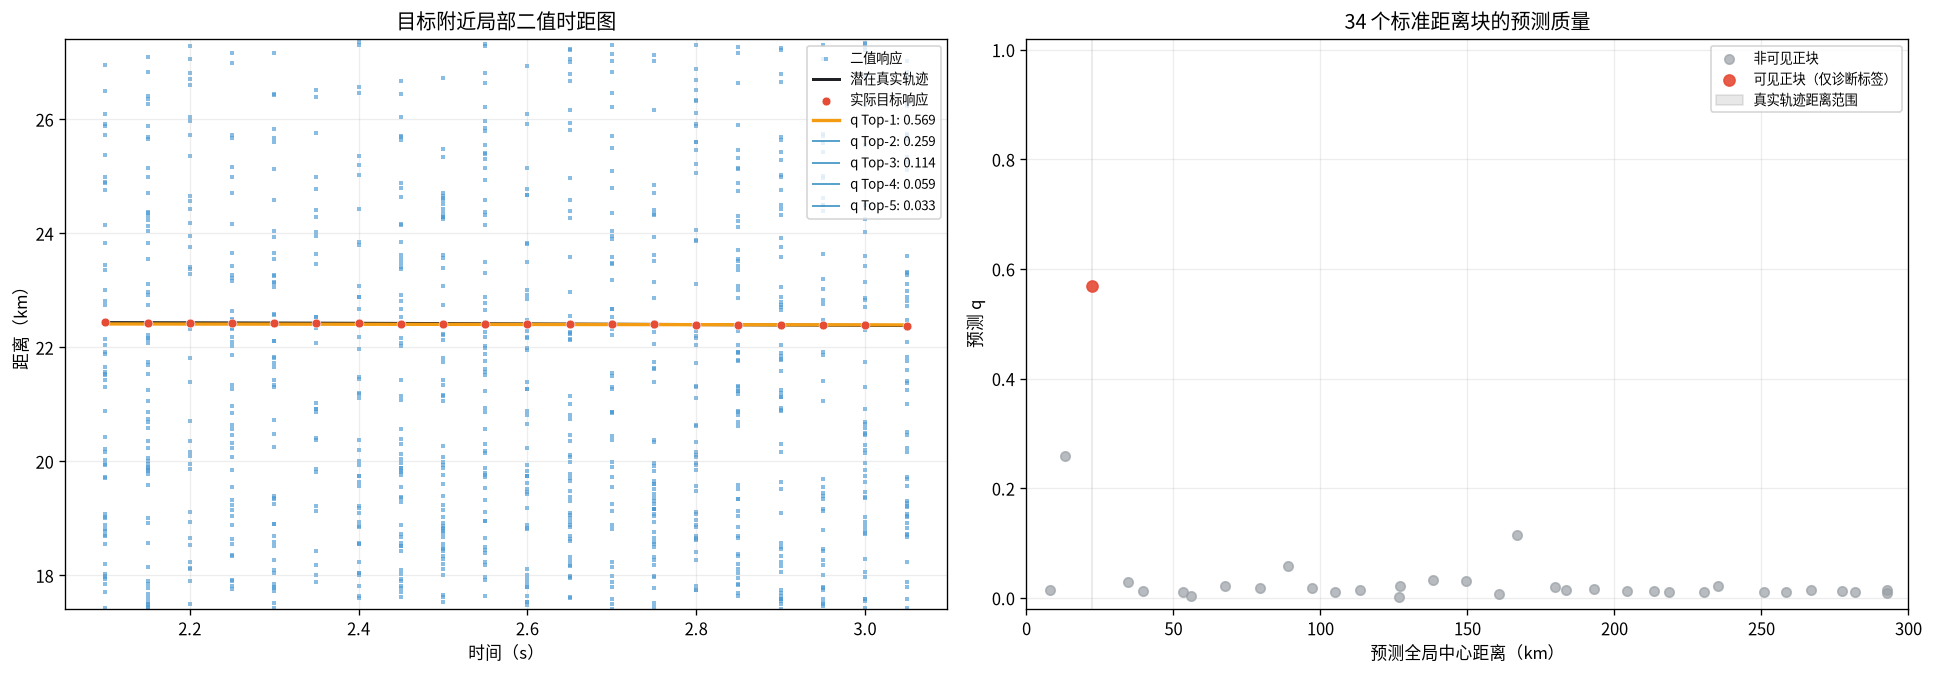

In [6]:
top_grid_indices = grid_order[:min(TOP_K, len(grid_order))]
target_plot_start = int(np.clip(
    np.floor(true_range_m.mean() - config.block_width_m / 2),
    0,
    config.range_bins - config.block_width_m,
))
target_plot_window = source.extract_window(time_start, target_plot_start, config)
observation_frames, observation_local_bins = np.nonzero(target_plot_window)
tau_zero = (config.frames_per_window - 1) / 2.0

figure, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)
axes[0].scatter(
    time_seconds[observation_frames],
    (target_plot_start + observation_local_bins) / 1000.0,
    s=4, marker='s', linewidths=0, alpha=0.65, color='#4C9AD4', label='二值响应',
)
axes[0].plot(time_seconds, true_range_m / 1000.0, color='#202124', lw=1.8, label='潜在真实轨迹')
axes[0].scatter(
    time_seconds[target_hit], target_hit_bin[target_hit] / 1000.0,
    s=28, color='#E64B35', edgecolor='white', linewidth=0.35, zorder=4, label='实际目标响应',
)
for rank, grid_index in enumerate(top_grid_indices, start=1):
    curve_m = (
        range_starts[grid_index] + predicted_rho_m[grid_index]
        + predicted_nu_mpf[grid_index] * (frame_axis - tau_zero)
    )
    axes[0].plot(
        time_seconds, curve_m / 1000.0,
        color='#0072B2' if rank > 1 else '#F39C12',
        lw=2.0 if rank == 1 else 1.2, alpha=1.0 if rank == 1 else 0.65,
        label=f'q Top-{rank}: {predicted_q[grid_index]:.3f}',
    )
axes[0].set(
    title='目标附近局部二值时距图', xlabel='时间（s）', ylabel='距离（km）',
    ylim=(target_plot_start / 1000.0, (target_plot_start + config.block_width_m) / 1000.0),
)
axes[0].grid(alpha=0.22)
axes[0].legend(fontsize=8, loc='upper right')

positive_mask = np.asarray([item['is_positive'] for item in labels_by_grid], dtype=bool)
axes[1].scatter(
    predicted_global_center_m[~positive_mask] / 1000.0, predicted_q[~positive_mask],
    s=32, color='#9AA0A6', alpha=0.7, label='非可见正块',
)
axes[1].scatter(
    predicted_global_center_m[positive_mask] / 1000.0, predicted_q[positive_mask],
    s=44, color='#E64B35', alpha=0.9, label='可见正块（仅诊断标签）', zorder=3,
)
axes[1].axvspan(true_range_m.min() / 1000.0, true_range_m.max() / 1000.0,
                 color='#202124', alpha=0.10, label='真实轨迹距离范围')
axes[1].set(
    title='34 个标准距离块的预测质量', xlabel='预测全局中心距离（km）', ylabel='预测 q',
    xlim=(0, config.range_bins / 1000.0), ylim=(-0.02, 1.02),
)
axes[1].grid(alpha=0.22)
axes[1].legend(fontsize=8)
plt.show()

## 7. 单独检查 q 排名候选块

`PLOT_CANDIDATE_RANK=0` 对应模型当前最高分块。若它不是目标所在块，图中不会出现真实轨迹或红色目标响应，这正是观察误检的方式。

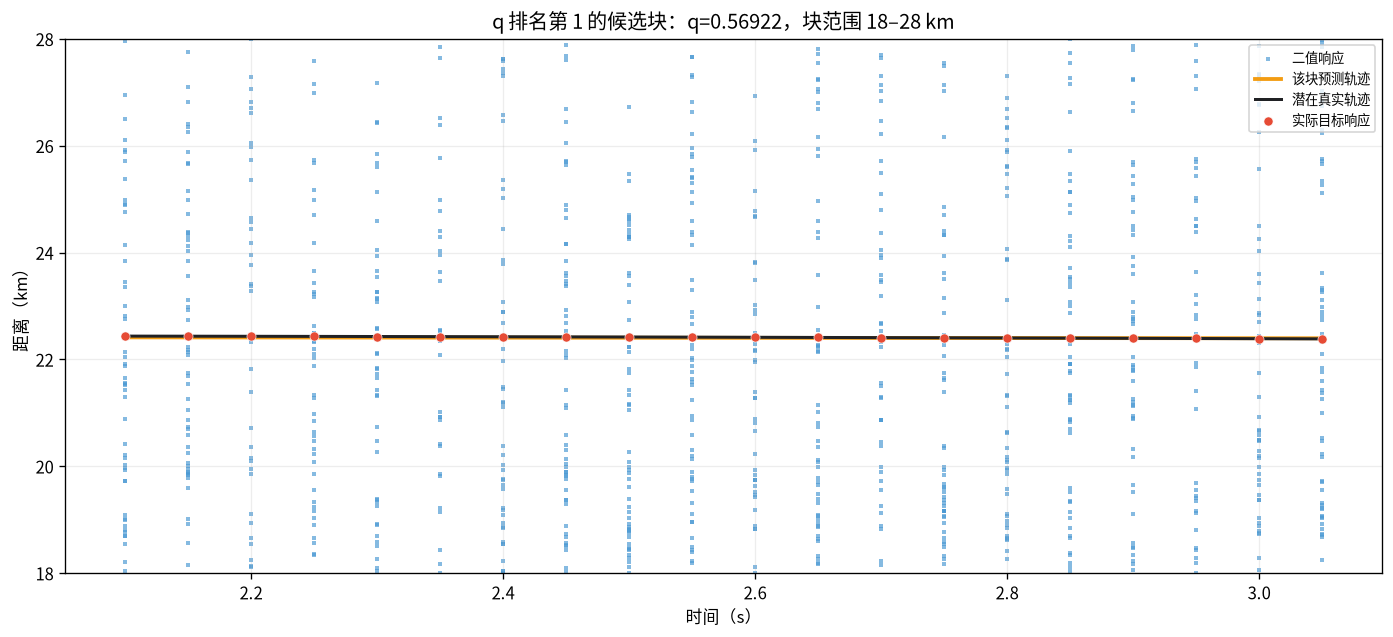

,q 排名,标准块索引,块起点（km）,块终点（km）,预测 q,预测全局中心（km）,预测斜率（m/帧）,真实 q*,轨迹关系,可见正样本
0,1,2,18.0,28.0,0.56922,22.40315,-0.90548,1.0,完整包含,True


In [7]:
if PLOT_CANDIDATE_RANK >= len(grid_order):
    raise IndexError(f'PLOT_CANDIDATE_RANK 应小于 {len(grid_order)}。')

grid_index = int(grid_order[PLOT_CANDIDATE_RANK])
candidate_start = int(range_starts[grid_index])
candidate_stop = candidate_start + config.block_width_m
candidate_window = source.extract_window(time_start, candidate_start, config)
candidate_frames, candidate_local_bins = np.nonzero(candidate_window)
candidate_curve_m = (
    candidate_start + predicted_rho_m[grid_index]
    + predicted_nu_mpf[grid_index] * (frame_axis - tau_zero)
)
true_inside = (true_range_m >= candidate_start) & (true_range_m < candidate_stop)
hit_inside = target_hit & (target_hit_bin >= candidate_start) & (target_hit_bin < candidate_stop)

figure, axis = plt.subplots(figsize=(11.5, 5.2), constrained_layout=True)
axis.scatter(
    time_seconds[candidate_frames], (candidate_start + candidate_local_bins) / 1000.0,
    s=4, marker='s', linewidths=0, alpha=0.68, color='#4C9AD4', label='二值响应',
)
axis.plot(time_seconds, candidate_curve_m / 1000.0, color='#F39C12', lw=2.3, label='该块预测轨迹')
if true_inside.any():
    axis.plot(time_seconds[true_inside], true_range_m[true_inside] / 1000.0,
              color='#202124', lw=1.8, label='潜在真实轨迹')
if hit_inside.any():
    axis.scatter(time_seconds[hit_inside], target_hit_bin[hit_inside] / 1000.0,
                 s=30, color='#E64B35', edgecolor='white', linewidth=0.35,
                 zorder=4, label='实际目标响应')
axis.set(
    title=(f'q 排名第 {PLOT_CANDIDATE_RANK + 1} 的候选块：'
           f'q={predicted_q[grid_index]:.5f}，块范围 {candidate_start / 1000:.0f}–{candidate_stop / 1000:.0f} km'),
    xlabel='时间（s）', ylabel='距离（km）',
    ylim=(candidate_start / 1000.0, candidate_stop / 1000.0),
)
axis.grid(alpha=0.22)
axis.legend(fontsize=8, loc='upper right')
plt.show()

display(candidate_table.iloc[[PLOT_CANDIDATE_RANK]].round(5))

## 5. 随机测试集样本的逐窗流式检查

这一节与参考笔记本的 `plot_random_test_sample_fit` 一致：先从测试集随机选择一份完整序列；对每个 $20$ 帧输入窗的全部 $34$ 个标准距离块推理；在该时间窗内选择预测 $q$ 最高的候选线，并外推后续 `time_stride` 帧。拼接这些后续帧预测即可得到整段流式轨迹。

本地 checkpoint 未附带训练时的 `resolved_config.json` 或原始 split manifest，因此这里按 `EVALUATION_SPLIT_SEED`、`EVALUATION_SOURCE_SAMPLE_LIMIT` 和当前的 $80/10/10$ 比例对本地数据可复现地构造测试集；这用于样本诊断，不计算 test loss。

In [8]:
def local_test_records() -> tuple[SourceRecord, ...]:
    """按训练 dataloader 相同的随机排列规则，构造本地固定测试序列集合。"""
    all_records = [record for record in discover_sources(DATA_ROOT) if record.path.is_file()]
    if config.source_sample_limit > 0:
        all_records = all_records[:config.source_sample_limit]
    split_rng = np.random.default_rng(config.split_seed)
    shuffled = [all_records[int(index)] for index in split_rng.permutation(len(all_records))]
    train_count = int(len(shuffled) * config.train_fraction)
    validation_count = int(len(shuffled) * config.val_fraction)
    test_records = tuple(shuffled[train_count + validation_count:])
    if not test_records:
        raise RuntimeError('本地数据不足以构造非空测试集。')
    return test_records


def unpack_all_frames(source: PackedSource, range_start: int, range_stop: int) -> np.ndarray:
    """从压缩观测中解包绘图所需的任意连续距离范围，返回 [F, width] 二值矩阵。"""
    if not 0 <= range_start < range_stop <= config.range_bins:
        raise IndexError('绘图区间必须位于 [0, range_bins] 内。')
    first_byte = range_start // 8
    bit_offset = range_start % 8
    width = range_stop - range_start
    byte_count = (bit_offset + width + 7) // 8
    unpacked = np.unpackbits(
        source.observation_packed[:, first_byte:first_byte + byte_count],
        axis=1,
        bitorder=config.packed_bitorder,
    )
    return unpacked[:, bit_offset:bit_offset + width]


def predict_stream_top_candidates(
    source: PackedSource,
    *,
    time_stride: int,
    window_batch_size: int,
    window_top_n: int,
) -> tuple[np.ndarray, np.ndarray, list[tuple[np.ndarray, np.ndarray, float]]]:
    """逐窗推理全部标准距离块，返回 q Top-1 外推轨迹及可选 Top-N 线段。"""
    if time_stride < 1 or window_batch_size < 1:
        raise ValueError('time_stride 和 window_batch_size 必须为正整数。')
    range_starts = np.asarray(standard_distance_starts(config), dtype=np.int64)
    if not 1 <= window_top_n <= len(range_starts):
        raise ValueError(f'window_top_n 应位于 [1, {len(range_starts)}]。')

    # 输入 [t, t+20) 后，最后允许外推到 t+20；因此 t 的最大值为 F-21。
    time_starts = np.arange(
        0, source.frames - config.frames_per_window, time_stride, dtype=np.int64
    )
    forecast_m = np.full(source.frames, np.nan, dtype=np.float64)
    top_q = np.full(len(time_starts), np.nan, dtype=np.float32)
    optional_top_segments: list[tuple[np.ndarray, np.ndarray, float]] = []
    tau_zero = (config.frames_per_window - 1) / 2.0

    for batch_start in range(0, len(time_starts), window_batch_size):
        batch_time_starts = time_starts[batch_start:batch_start + window_batch_size]
        batch_inputs = []
        for time_start in batch_time_starts:
            for range_start in range_starts:
                raw_window = source.extract_window(int(time_start), int(range_start), config)
                rearranged = rearrange_distance_channels(raw_window, config)
                batch_inputs.append(torch.from_numpy(rearranged.astype(np.float32, copy=False)))

        model_input = torch.stack(batch_inputs).to(device, non_blocking=device.type == 'cuda')
        with torch.inference_mode():
            prediction = model(model_input)
        batch_size = len(batch_time_starts)
        prediction_q = prediction['q'].detach().float().cpu().numpy().reshape(batch_size, -1)
        prediction_rho = prediction['rho_m'].detach().float().cpu().numpy().reshape(batch_size, -1)
        prediction_nu = prediction['nu_mpf'].detach().float().cpu().numpy().reshape(batch_size, -1)
        ranked_indices = np.argsort(-prediction_q, axis=1, kind='stable')[:, :window_top_n]

        for local_index, time_start in enumerate(batch_time_starts):
            forecast_start = int(time_start) + config.frames_per_window
            forecast_stop = min(forecast_start + time_stride, source.frames)
            forecast_frames = np.arange(forecast_start, forecast_stop, dtype=np.int64)
            local_future_frames = forecast_frames.astype(np.float64) - float(time_start)
            candidates = ranked_indices[local_index]
            candidate_ranges_m = (
                range_starts[candidates, None]
                + prediction_rho[local_index, candidates, None]
                + prediction_nu[local_index, candidates, None] * (local_future_frames[None, :] - tau_zero)
            )
            forecast_m[forecast_frames] = candidate_ranges_m[0]
            top_q[batch_start + local_index] = prediction_q[local_index, candidates[0]]

            if window_top_n > 1:
                reference_q = float(prediction_q[local_index, candidates[0]])
                for candidate_index, candidate in enumerate(candidates[1:], start=1):
                    q_value = float(prediction_q[local_index, candidate])
                    alpha = q_value / reference_q if reference_q > 0.0 else 1.0
                    optional_top_segments.append((
                        forecast_frames * 0.05,
                        candidate_ranges_m[candidate_index] / 1_000.0,
                        float(np.clip(alpha, 0.0, 1.0)),
                    ))

    return forecast_m, top_q, optional_top_segments


def plot_test_source_fit(
    record: SourceRecord,
    *,
    time_stride: int = 1,
    margin_m: float = 5_000.0,
    point_size: float = 2.0,
    window_batch_size: int = 8,
    show_window_top_n: bool = False,
    window_top_n: int = 1,
) -> tuple[dict[str, object], plt.Figure]:
    """以流式方式检查一份测试序列；不读取或计算任何测试损失。"""
    if margin_m < 0.0 or point_size <= 0.0:
        raise ValueError('margin_m 必须非负，point_size 必须为正。')
    effective_top_n = window_top_n if show_window_top_n else 1
    source = PackedSource(record)
    forecast_m, top_q, optional_top_segments = predict_stream_top_candidates(
        source,
        time_stride=time_stride,
        window_batch_size=window_batch_size,
        window_top_n=effective_top_n,
    )
    covered = np.isfinite(forecast_m)
    if not covered.any():
        raise RuntimeError('流式推理没有产生任何未来帧预测。')

    true_range_m = source.target_true_range_m.astype(np.float64, copy=False)
    target_hit = source.target_hit
    target_hit_bin = source.target_hit_bin
    time_seconds = np.arange(source.frames, dtype=np.float64) * 0.05
    local_start = max(0, int(np.floor(true_range_m.min() - margin_m)))
    local_stop = min(config.range_bins, int(np.ceil(true_range_m.max() + margin_m + 1.0)))
    local_observation = unpack_all_frames(source, local_start, local_stop)
    observation_frames, observation_bins = np.nonzero(local_observation)

    with np.load(record.path, allow_pickle=False) as archive:
        background_probability_1m = archive['background_probability_1m'].astype(np.float64, copy=False)
    background_probability_1km = background_probability_1m.reshape(-1, 1_000).mean(axis=1)
    background_centres_km = np.arange(len(background_probability_1km)) + 0.5
    forecast_mae_m = float(np.mean(np.abs(forecast_m[covered] - true_range_m[covered])))

    figure, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    axes[0, 0].semilogy(background_centres_km, background_probability_1km, color='#4C78A8', lw=1.3)
    axes[0, 0].axvspan(true_range_m.min() / 1_000.0, true_range_m.max() / 1_000.0,
                       color='#E64B35', alpha=0.15, label='该目标经过距离')
    axes[0, 0].set(title='该序列的背景占据概率', xlabel='距离（km）', ylabel='每 1 m bin 概率', xlim=(0, 300))
    axes[0, 0].legend(fontsize=8)

    for axis in (axes[0, 1], axes[1, 0], axes[1, 1]):
        axis.scatter(
            time_seconds[observation_frames], (local_start + observation_bins) / 1_000.0,
            s=point_size, marker='s', linewidths=0, alpha=0.68, color='#4C9AD4',
            rasterized=True, label='二值响应',
        )
        axis.set(xlabel='时间（s）', ylabel='距离（km）', ylim=(local_start / 1_000.0, local_stop / 1_000.0))
        axis.grid(alpha=0.22)

    axes[0, 1].set(title='局部二值时距图（目标未标注）')
    axes[0, 1].legend(fontsize=8)

    axes[1, 0].plot(time_seconds, true_range_m / 1_000.0, color='#202124', lw=1.5, label='潜在真实轨迹')
    axes[1, 0].scatter(time_seconds[target_hit], target_hit_bin[target_hit] / 1_000.0,
                       s=13, color='#E64B35', zorder=3, label='实际目标响应')
    axes[1, 0].set(title='二值响应与真实轨迹（仅诊断）')
    axes[1, 0].legend(fontsize=8)

    axes[1, 1].plot(time_seconds, true_range_m / 1_000.0, color='#666666', lw=1.1, ls='--', label='潜在真实轨迹')
    if show_window_top_n:
        for segment_index, (segment_time, segment_range, alpha) in enumerate(optional_top_segments):
            axes[1, 1].plot(segment_time, segment_range, color='#0072B2', lw=0.8, alpha=alpha,
                            label=f'每窗 q Top-{window_top_n} 其他候选' if segment_index == 0 else None)
    axes[1, 1].plot(time_seconds[covered], forecast_m[covered] / 1_000.0,
                    color='#F39C12', lw=1.9, label='每窗 q Top-1 未来预测', zorder=3)
    axes[1, 1].axvspan(0.0, config.frames_per_window * 0.05, color='#888888', alpha=0.10, label='首次输入窗')
    axes[1, 1].set(title=f'流式未来预测：MAE {forecast_mae_m:.1f} m，覆盖率 {covered.mean():.1%}')
    axes[1, 1].legend(fontsize=8)

    summary = {
        '数据划分': '本地固定测试集（80/10/10）',
        '数据源 ID': record.source_id,
        '序列帧数': source.frames,
        '输入时间窗长度（帧）': config.frames_per_window,
        '时间窗步进（帧）': time_stride,
        '流式推理时间窗数': len(top_q),
        '每窗标准距离块数': len(standard_distance_starts(config)),
        '流式推理局部块数': int(len(top_q) * len(standard_distance_starts(config))),
        '每窗主候选策略': '全部标准距离块中 q Top-1',
        '未来预测覆盖帧数': int(covered.sum()),
        '未来预测覆盖率': float(covered.mean()),
        '未来预测相对潜在轨迹 MAE（m）': forecast_mae_m,
        '实际目标响应总数': int(target_hit.sum()),
    }
    plt.show()
    return summary, figure


def plot_random_test_sample_fit(
    *,
    time_stride: int = 1,
    seed: int | None = None,
    show_window_top_n: bool = False,
    window_top_n: int = 1,
) -> tuple[dict[str, object], plt.Figure]:
    """从本地测试集重新随机选择一份序列，并绘制其逐窗流式预测。"""
    test_records = local_test_records()
    random_generator = np.random.default_rng(seed)
    record_index = int(random_generator.integers(len(test_records)))
    summary, figure = plot_test_source_fit(
        test_records[record_index],
        time_stride=time_stride,
        show_window_top_n=show_window_top_n,
        window_top_n=window_top_n,
    )
    summary['测试集数据源数'] = len(test_records)
    summary['测试集内索引'] = record_index
    return summary, figure


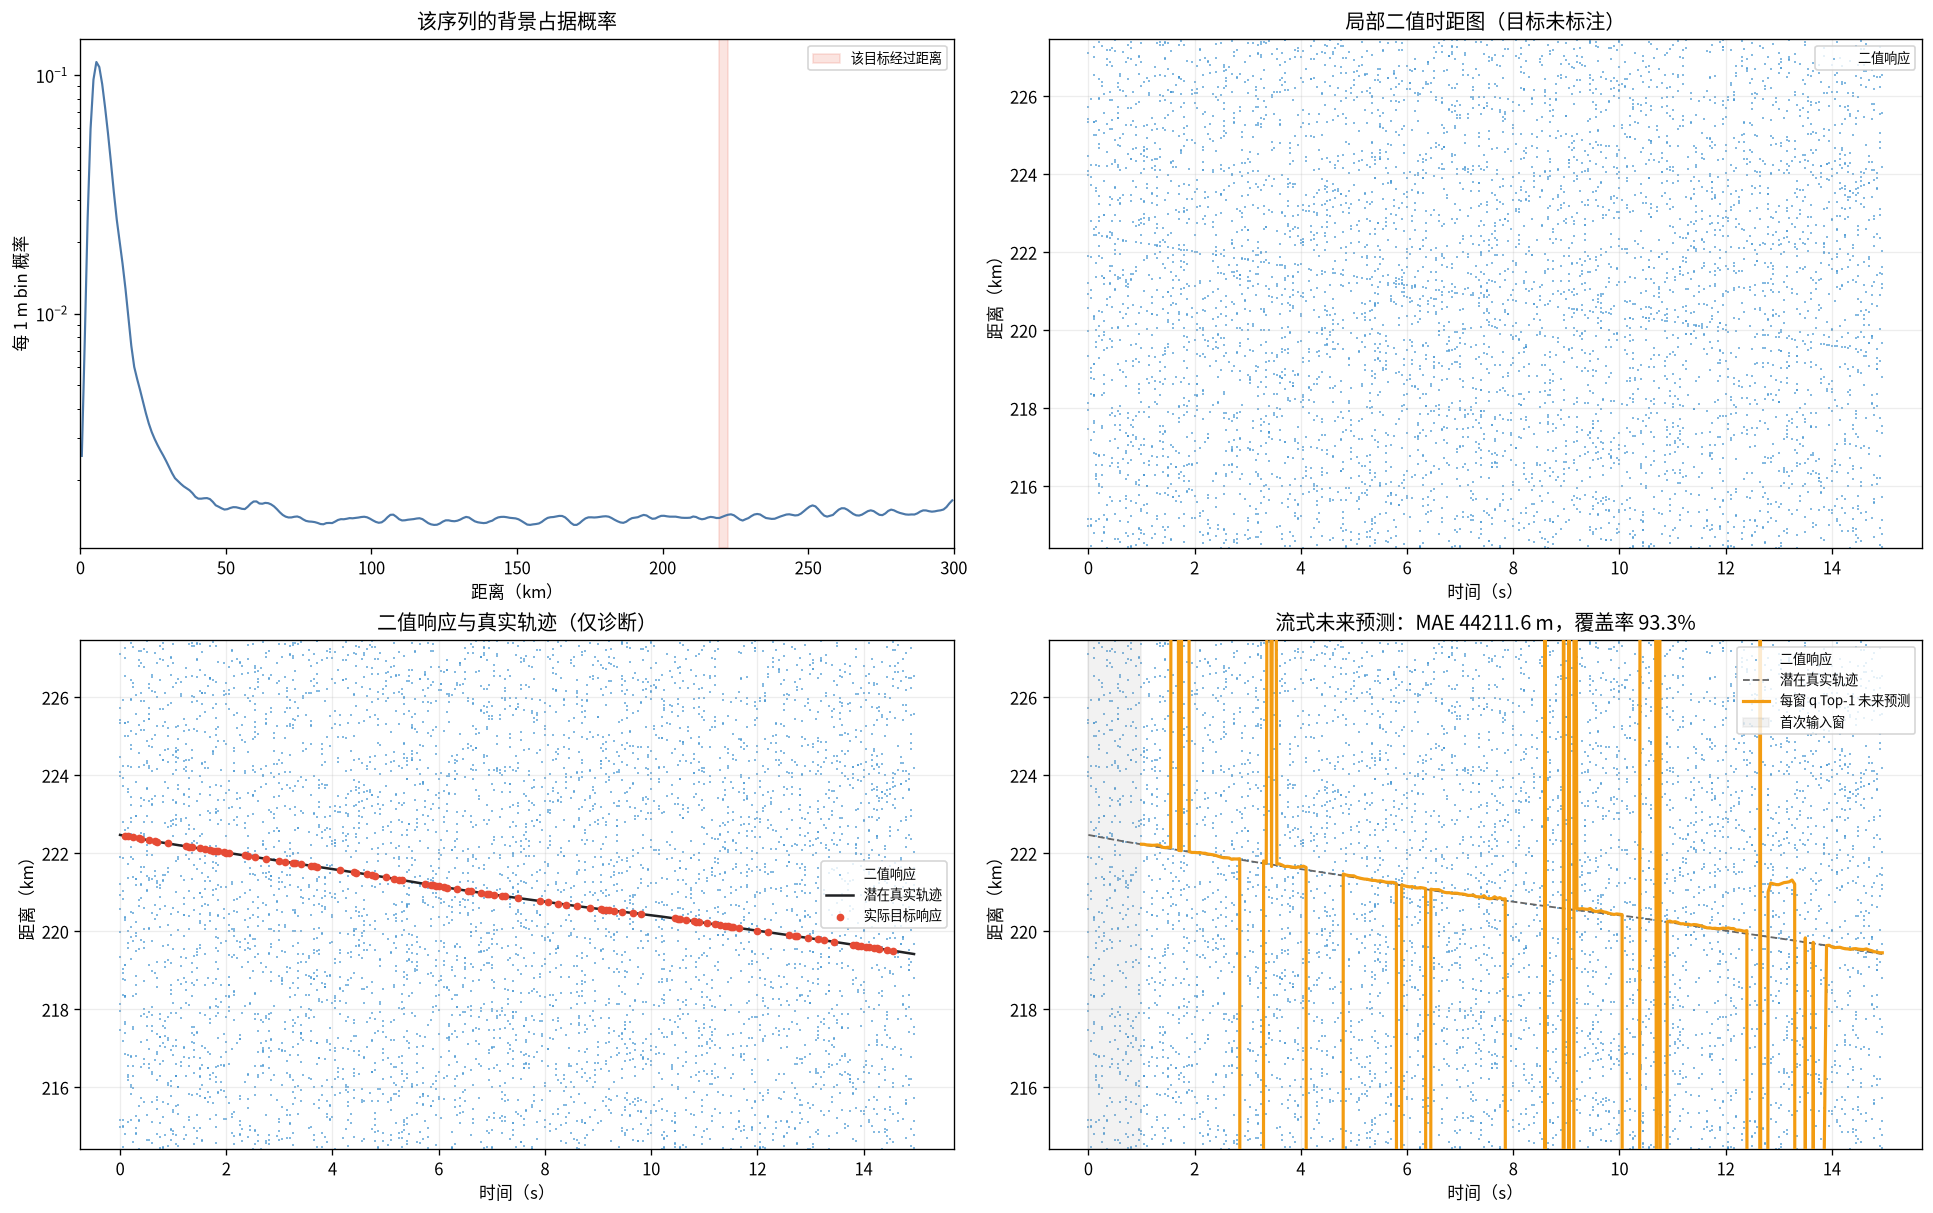

,数值
数据划分,本地固定测试集（80/10/10）
数据源 ID,dataset1_synthetic_0165
序列帧数,300
输入时间窗长度（帧）,20
时间窗步进（帧）,1
流式推理时间窗数,280
每窗标准距离块数,34
流式推理局部块数,9520
每窗主候选策略,全部标准距离块中 q Top-1
未来预测覆盖帧数,280


In [15]:
# 重复运行本单元格即可从 test 集重新随机选择一个样本。
random_test_summary, random_test_figure = plot_random_test_sample_fit(
    time_stride=1,
    seed=RANDOM_TEST_SEED,
    show_window_top_n=False,
    window_top_n=1,
)
display(pd.Series(random_test_summary, name='数值').to_frame())


## 下一步

- 修改 `SAMPLE_ID`、`WINDOW_START_FRAME` 或 `RANDOM_SEED`，重复检查不同合成样本；
- 修改 `PLOT_CANDIDATE_RANK`，观察 Top-$q$ 候选中的误检或重复候选；
- 若要计算固定验证/测试网格 loss，需要另行恢复训练时的完整配置与数据划分；本笔记本按当前需求暂不包含该部分。